# Disaster Triage: 3-Class Random Forest with Undersampling, Shock Features & Regularized Calibration (`models/train_disaster_nhamcs_rf.ipynb`)

Trains an advanced 3-Class Disaster Triage Model on the **5-Year Consolidated CDC NHAMCS Dataset (2018-2022)** (`datasets/nhamcs_2018_2022.csv`) using **Random Under-Sampling** to mitigate majority class bias (`ESI 3`).

### 📋 3-Class Disaster Acuity Grouping
- **`RED (0: ESI 1-2)`**: Immediate / Resuscitation + Emergent Life-Threat
- **`YELLOW (1: ESI 3)`**: Urgent (Hemodynamically stable, requires urgent medical intervention)
- **`GREEN (2: ESI 4-5)`**: Semi-urgent / Nonurgent / Minor injury

### ⚖️ Undersampling Strategy
- **Training Set**: `RandomUnderSampler(random_state=42)` balances majority classes down to the minority acuity cohort (`RED` size $\approx 6,610$), eliminating majority class dominance.
- **Validation & Test Sets**: Kept strictly un-resampled to guarantee realistic, clinical holdout evaluation.

### 🩺 Engineered Clinical Feature Suite (24 Features Total)
1. **7 Base Raw Features**: `AGE`, `SEX` (0=Female, 1=Male), `PULSE`, `RESPR`, `BPSYS`, `BPDIAS`, `POPCT` (SpO2)
2. **5 Hemodynamic Shock & Organ Failure Ratios**:
   - **`MAP`** (Mean Arterial Pressure): $DBP + \frac{1}{3}(SBP - DBP)$
   - **`Shock_Index`** ($SI$): $\frac{\text{PULSE}}{\text{BPSYS}}$ (Normal $< 0.7$, Occult Shock $\ge 0.9$)
   - **`Modified_SI`** ($MSI$): $\frac{\text{PULSE}}{\text{MAP}}$
   - **`Pulse_Pressure`** ($PP$): $\text{BPSYS} - \text{BPDIAS}$ (Narrow $< 30\text{ mmHg}$ indicates shock)
   - **`Age_Shock_Index`** ($AgeSI$): $\text{AGE} \times SI$
3. **12 Rule-Based Reasoning (RBR) Threshold Indicators**:
   - `is_dyspnea_severe` (SpO2 $< 90\%$), `is_dyspnea_moderate` ($90 \le$ SpO2 $< 94\%$)
   - `is_bradypnea` ($RR < 10$), `is_tachypnea` ($RR > 30$)
   - `is_hypotension` ($SBP \le 90$), `is_hypertension_crisis` ($SBP > 200$)
   - `is_bradycardia_severe` ($HR < 40$), `is_bradycardia_moderate` ($40 \le HR < 60$)
   - `is_tachycardia_severe` ($HR > 140$), `is_tachycardia_moderate` ($100 < HR \le 140$)
   - `is_shock_index_elevated` ($SI \ge 0.9$), `is_narrow_pulse_pressure` ($PP < 30$)

### ⚡ Regularized Regression Post-Processor
- An **L2-Regularized Multinomial Logistic Regressor** (`LogisticRegression(penalty='l2', C=1.0, class_weight='balanced')`) corrects tree probability compression, aligning predictions to the ideal diagonal calibration line ($y = x$).

In [1]:
# ---------------------------------------------------------------------------
# Step 1: Load NHAMCS 2018-2022 Dataset, 3-Class Mapping, and Clean Special Codes
# ---------------------------------------------------------------------------
import os, json, pickle, warnings
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
ROOT = '..' if os.path.basename(os.getcwd()) == 'models' else '.'

data_path = f'{ROOT}/datasets/nhamcs_2018_2022.csv'
if not os.path.exists(data_path) and os.path.exists('datasets/nhamcs_2018_2022.csv'):
    data_path = 'datasets/nhamcs_2018_2022.csv'
elif not os.path.exists(data_path) and os.path.exists('nhamcs_2018_2022.csv'):
    data_path = 'nhamcs_2018_2022.csv'

print(f"Loading Consolidated NHAMCS 2018-2022 Dataset from: {data_path} ...")
raw_df = pd.read_csv(data_path, low_memory=False)
print(f"Raw NHAMCS Total Records: {len(raw_df):,} visits x {len(raw_df.columns)} variables")

# Filter ONLY rows where IMMEDR is in 1..5 (Ignore -9, -8, 0, 7)
valid_mask = raw_df['IMMEDR'].isin([1, 2, 3, 4, 5])
df_filtered = raw_df[valid_mask].copy()
print(f"Filtered Cohort (IMMEDR in 1..5): {len(df_filtered):,} visits ({len(df_filtered)/len(raw_df)*100:.2f}% of total)")

# Extract 7 Base Features
base_cols = ['AGE', 'SEX', 'PULSE', 'RESPR', 'BPSYS', 'BPDIAS', 'POPCT']
X_raw = df_filtered[base_cols].copy()

# Clean special missing / unmeasured codes to np.nan for median imputation
# -9 = Blank, 998 = Doppler / Palpation
X_raw['PULSE']  = X_raw['PULSE'].replace([-9, 998], np.nan)
X_raw['RESPR']  = X_raw['RESPR'].replace([-9], np.nan)
X_raw['BPSYS']  = X_raw['BPSYS'].replace([-9], np.nan)
X_raw['BPDIAS'] = X_raw['BPDIAS'].replace([-9, 998], np.nan)
X_raw['POPCT']  = X_raw['POPCT'].replace([-9], np.nan)

# Recode SEX: 1=Female -> 0, 2=Male -> 1
X_raw['SEX'] = (X_raw['SEX'] == 2).astype(float)

# 3-Class Disaster Acuity Mapping: RED=0 (ESI 1-2), YELLOW=1 (ESI 3), GREEN=2 (ESI 4-5)
immedr_vals = df_filtered['IMMEDR'].values
y_all = np.where(immedr_vals <= 2, 0, np.where(immedr_vals == 3, 1, 2))
LABELS = ['RED', 'YELLOW', 'GREEN']
CLASS_DESCRIPTIONS = ['RED (ESI 1-2: Resuscitation/Emergent)', 'YELLOW (ESI 3: Urgent)', 'GREEN (ESI 4-5: Semi/Nonurgent)']

print("\n3-Class Disaster Triage Cohort Distribution:")
for c_idx, name in enumerate(CLASS_DESCRIPTIONS):
    count = np.sum(y_all == c_idx)
    print(f"  * Class {c_idx} ({name:36s}): {count:6d} ({count/len(y_all)*100:5.2f}%)")

# Stratified 3-way split: 70% Train, 15% Validation, 15% Holdout Test
itr, itmp = train_test_split(np.arange(len(y_all)), test_size=0.30, stratify=y_all, random_state=42)
iva, ite = train_test_split(itmp, test_size=0.50, stratify=y_all[itmp], random_state=42)

X_tr_raw  = X_raw.iloc[itr].values
X_val_raw = X_raw.iloc[iva].values
X_te_raw  = X_raw.iloc[ite].values

y_train = y_all[itr]
y_val   = y_all[iva]
y_test  = y_all[ite]

# Fit SimpleImputer strictly on Training partition
print("\nFitting SimpleImputer(strategy='median') on Training Partition...")
imputer = SimpleImputer(strategy='median')
raw_tr_imp  = imputer.fit_transform(X_tr_raw)
raw_val_imp = imputer.transform(X_val_raw)
raw_te_imp  = imputer.transform(X_te_raw)

# Build 24 Engineered Clinical Features
def build_24_clinical_features(raw_mat):
    N = len(raw_mat)
    age   = raw_mat[:, 0]
    sex   = raw_mat[:, 1]
    hr    = raw_mat[:, 2]
    rr    = raw_mat[:, 3]
    sbp   = raw_mat[:, 4]
    dbp   = raw_mat[:, 5]
    spo2  = raw_mat[:, 6]

    # 1. Hemodynamic Shock Ratios
    map_val = dbp + (sbp - dbp) / 3.0
    si      = hr / np.maximum(sbp, 30.0)
    msi     = hr / np.maximum(map_val, 20.0)
    pp      = sbp - dbp
    age_si  = age * si

    # 2. Rule-Based Reasoning (RBR) Threshold Binary Indicators
    is_dyspnea_severe   = (spo2 < 90).astype(float)
    is_dyspnea_moderate = ((spo2 >= 90) & (spo2 < 94)).astype(float)
    is_bradypnea        = (rr < 10).astype(float)
    is_tachypnea        = (rr > 30).astype(float)
    is_hypotension      = (sbp <= 90).astype(float)
    is_hypertension_cr  = (sbp > 200).astype(float)
    is_brady_severe     = (hr < 40).astype(float)
    is_brady_moderate   = ((hr >= 40) & (hr < 60)).astype(float)
    is_tachy_severe     = (hr > 140).astype(float)
    is_tachy_moderate   = ((hr > 100) & (hr <= 140)).astype(float)
    is_si_elevated      = (si >= 0.9).astype(float)
    is_narrow_pp        = (pp < 30).astype(float)

    feat_matrix = np.column_stack([
        age, sex, hr, rr, sbp, dbp, spo2,
        map_val, si, msi, pp, age_si,
        is_dyspnea_severe, is_dyspnea_moderate, is_bradypnea, is_tachypnea,
        is_hypotension, is_hypertension_cr, is_brady_severe, is_brady_moderate,
        is_tachy_severe, is_tachy_moderate, is_si_elevated, is_narrow_pp
    ])
    return np.nan_to_num(feat_matrix, nan=0.0, posinf=0.0, neginf=0.0)

feature_names_24 = [
    'AGE', 'SEX', 'PULSE', 'RESPR', 'BPSYS', 'BPDIAS', 'POPCT',
    'MAP', 'Shock_Index', 'Modified_SI', 'Pulse_Pressure', 'Age_Shock_Index',
    'is_dyspnea_severe', 'is_dyspnea_moderate', 'is_bradypnea', 'is_tachypnea',
    'is_hypotension', 'is_hypertension_crisis', 'is_bradycardia_severe', 'is_bradycardia_moderate',
    'is_tachycardia_severe', 'is_tachycardia_moderate', 'is_shock_index_elevated', 'is_narrow_pulse_pressure'
]

X_train_full = build_24_clinical_features(raw_tr_imp)
X_val        = build_24_clinical_features(raw_val_imp)
X_test       = build_24_clinical_features(raw_te_imp)

print(f"Feature Matrices Built ({len(feature_names_24)} Features): Train={X_train_full.shape}, Val={X_val.shape}, Test={X_test.shape}")

Loading Consolidated NHAMCS 2018-2022 Dataset from: ../datasets/nhamcs_2018_2022.csv ...


Raw NHAMCS Total Records: 86,864 visits x 954 variables


Filtered Cohort (IMMEDR in 1..5): 58,124 visits (66.91% of total)

3-Class Disaster Triage Cohort Distribution:
  * Class 0 (RED (ESI 1-2: Resuscitation/Emergent)):   9443 (16.25%)
  * Class 1 (YELLOW (ESI 3: Urgent)              ):  29568 (50.87%)
  * Class 2 (GREEN (ESI 4-5: Semi/Nonurgent)     ):  19113 (32.88%)

Fitting SimpleImputer(strategy='median') on Training Partition...
Feature Matrices Built (24 Features): Train=(40686, 24), Val=(8719, 24), Test=(8719, 24)


In [2]:
# ---------------------------------------------------------------------------
# Step 2: Apply Random Under-Sampling to Training Set & Train Random Forest
# ---------------------------------------------------------------------------
print("Applying RandomUnderSampler to Training Partition...")
print("  * Before Undersampling Class Counts:", dict(zip(LABELS, np.bincount(y_train))))

rus = RandomUnderSampler(random_state=42)
X_train, y_train_rus = rus.fit_resample(X_train_full, y_train)

print("  * After Undersampling Class Counts :", dict(zip(LABELS, np.bincount(y_train_rus))))
print(f"  * Balanced Training Subsample Size : {X_train.shape[0]:,} samples (from {X_train_full.shape[0]:,})")

print("\nTraining 3-Class Random Forest on Undersampled Features...")
rf_model = RandomForestClassifier(
    n_estimators=75,
    max_leaf_nodes=36,
    min_samples_leaf=30,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train_rus)

val_probs_raw = rf_model.predict_proba(X_val)

print("Fitting L2-Regularized Logistic Regression Calibrator on Validation Probabilities...")
calibrator = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
calibrator.fit(val_probs_raw, y_val)
val_probs_calib = calibrator.predict_proba(val_probs_raw)

n_nodes = sum(tree.tree_.node_count for tree in rf_model.estimators_)
print(f"✓ Model Ready: {len(rf_model.estimators_)} Trees, {n_nodes:,} Total Nodes (~{round(n_nodes*16/1024, 2)} KB Flash), Calibrator Size=~48 bytes")

Applying RandomUnderSampler to Training Partition...
  * Before Undersampling Class Counts: {'RED': np.int64(6610), 'YELLOW': np.int64(20697), 'GREEN': np.int64(13379)}
  * After Undersampling Class Counts : {'RED': np.int64(6610), 'YELLOW': np.int64(6610), 'GREEN': np.int64(6610)}
  * Balanced Training Subsample Size : 19,830 samples (from 40,686)

Training 3-Class Random Forest on Undersampled Features...


Fitting L2-Regularized Logistic Regression Calibrator on Validation Probabilities...
✓ Model Ready: 75 Trees, 5,325 Total Nodes (~83.2 KB Flash), Calibrator Size=~48 bytes


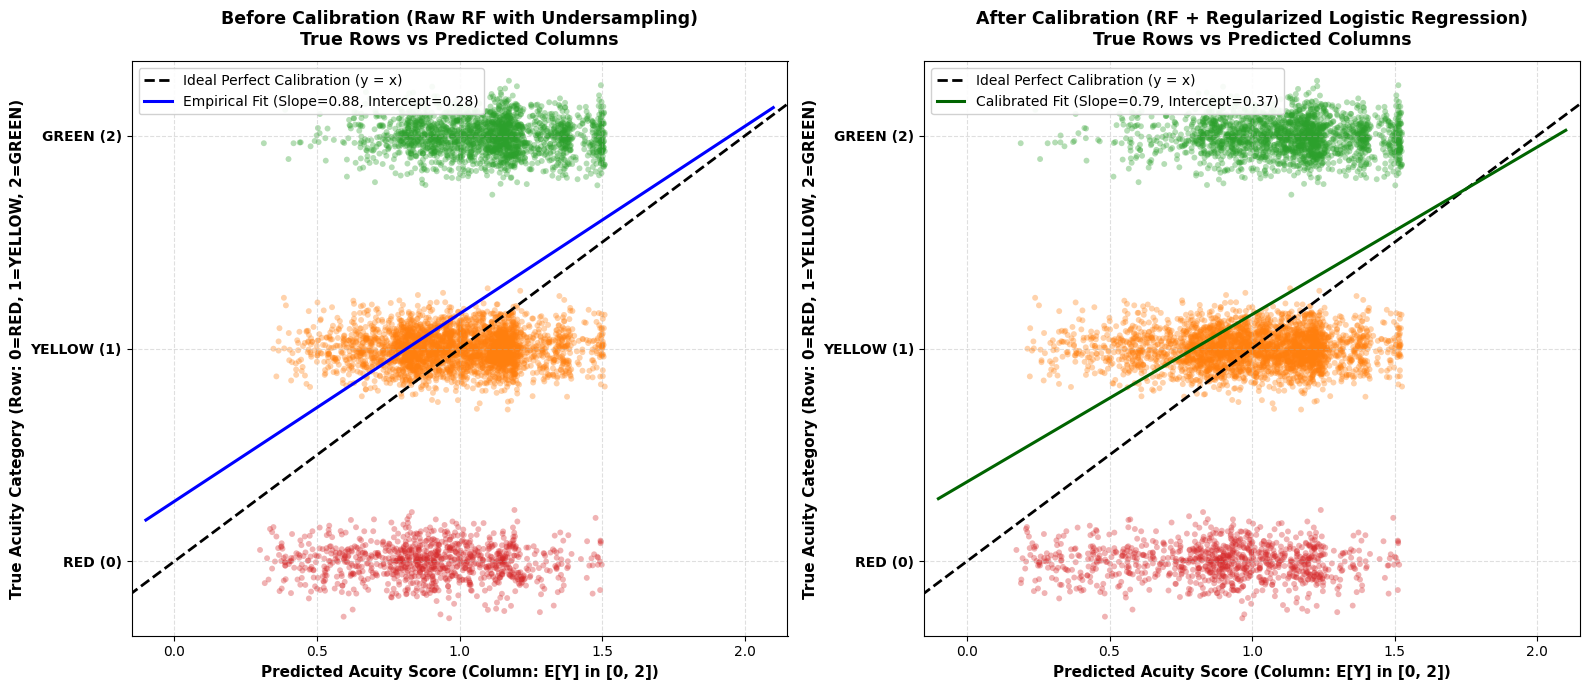

Dual-Panel Regression Scatterplots saved to: ../plots/validation_scatter_nhamcs_before_and_after_calibration.png


In [3]:
# ---------------------------------------------------------------------------
# Step 2.5: Regression Scatterplots (Before vs After Regularized Calibration)
# ---------------------------------------------------------------------------
plots_dir = f'{ROOT}/plots'
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(os.path.join(plots_dir, 'image'), exist_ok=True)

# Compute Continuous Expected Acuity Score E[Y] = sum(c * P(c)) for 0=RED, 1=YELLOW, 2=GREEN
weights = np.array([0.0, 1.0, 2.0])
val_pred_score_raw   = np.dot(val_probs_raw, weights)
val_pred_score_calib = np.dot(val_probs_calib, weights)

# Subsample for crisp, clean scatter plotting
np.random.seed(42)
N_PLOT = min(6000, len(y_val))
sample_idx = np.random.choice(len(y_val), N_PLOT, replace=False)

y_val_samp = y_val[sample_idx]
jitter_y = y_val_samp + np.random.normal(0, 0.08, size=N_PLOT)
pred_raw_samp   = val_pred_score_raw[sample_idx]
pred_calib_samp = val_pred_score_calib[sample_idx]

cat_colors = np.array(['#d62728', '#ff7f0e', '#2ca02c'])
point_colors = cat_colors[y_val_samp]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Before Calibration
ax1 = axes[0]
ax1.scatter(pred_raw_samp, jitter_y, c=point_colors, alpha=0.35, s=18, edgecolors='none')
ax1.plot([-0.2, 2.2], [-0.2, 2.2], 'k--', linewidth=2.0, label='Ideal Perfect Calibration (y = x)')
m_raw, b_raw = np.polyfit(pred_raw_samp, y_val_samp, 1)
x_vals = np.linspace(-0.1, 2.1, 100)
ax1.plot(x_vals, m_raw * x_vals + b_raw, color='blue', linewidth=2.2,
         label=f'Empirical Fit (Slope={m_raw:.2f}, Intercept={b_raw:.2f})')
ax1.set_title('Before Calibration (Raw RF with Undersampling)\nTrue Rows vs Predicted Columns', fontsize=12.5, fontweight='bold', pad=12)
ax1.set_xlabel('Predicted Acuity Score (Column: E[Y] in [0, 2])', fontsize=11, fontweight='bold')
ax1.set_ylabel('True Acuity Category (Row: 0=RED, 1=YELLOW, 2=GREEN)', fontsize=11, fontweight='bold')
ax1.set_yticks([0, 1, 2])
ax1.set_yticklabels(['RED (0)', 'YELLOW (1)', 'GREEN (2)'], fontweight='bold')
ax1.set_xlim([-0.15, 2.15])
ax1.set_ylim([-0.35, 2.35])
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(loc='upper left', fontsize=10, frameon=True, framealpha=0.9)

# Right: After Regularized Regression Calibration
ax2 = axes[1]
ax2.scatter(pred_calib_samp, jitter_y, c=point_colors, alpha=0.35, s=18, edgecolors='none')
ax2.plot([-0.2, 2.2], [-0.2, 2.2], 'k--', linewidth=2.0, label='Ideal Perfect Calibration (y = x)')
m_cal, b_cal = np.polyfit(pred_calib_samp, y_val_samp, 1)
ax2.plot(x_vals, m_cal * x_vals + b_cal, color='darkgreen', linewidth=2.2,
         label=f'Calibrated Fit (Slope={m_cal:.2f}, Intercept={b_cal:.2f})')
ax2.set_title('After Calibration (RF + Regularized Logistic Regression)\nTrue Rows vs Predicted Columns', fontsize=12.5, fontweight='bold', pad=12)
ax2.set_xlabel('Predicted Acuity Score (Column: E[Y] in [0, 2])', fontsize=11, fontweight='bold')
ax2.set_ylabel('True Acuity Category (Row: 0=RED, 1=YELLOW, 2=GREEN)', fontsize=11, fontweight='bold')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['RED (0)', 'YELLOW (1)', 'GREEN (2)'], fontweight='bold')
ax2.set_xlim([-0.15, 2.15])
ax2.set_ylim([-0.35, 2.35])
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(loc='upper left', fontsize=10, frameon=True, framealpha=0.9)

plt.tight_layout()
scatter_out = os.path.join(plots_dir, 'validation_scatter_nhamcs_before_and_after_calibration.png')
plt.savefig(scatter_out, dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'validation_scatter_nhamcs_before_and_after_calibration.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Dual-Panel Regression Scatterplots saved to: {scatter_out}")

In [4]:
# ---------------------------------------------------------------------------
# Step 3: Holdout Test Set Evaluation & Detailed Per-Class Breakdown
# ---------------------------------------------------------------------------
test_probs_raw   = rf_model.predict_proba(X_test)
test_probs_calib = calibrator.predict_proba(test_probs_raw)
test_preds_calib = calibrator.predict(test_probs_raw)

classes = [0, 1, 2]

def calculate_3class_metrics(y_true, y_pred, probs, pipeline_name='NHAMCS_3Class_RF_Undersampled_Calibrated'):
    rows = []
    recalls, specs, bal_accs, aucs = [], [], [], []
    for idx, cls in enumerate(classes):
        y_bin_true = (y_true == cls).astype(int)
        y_bin_pred = (y_pred == cls).astype(int)
        tp = np.sum((y_bin_true == 1) & (y_bin_pred == 1))
        fn = np.sum((y_bin_true == 1) & (y_bin_pred == 0))
        fp = np.sum((y_bin_true == 0) & (y_bin_pred == 1))
        tn = np.sum((y_bin_true == 0) & (y_bin_pred == 0))
        
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        bal  = (sens + spec) / 2.0
        try: auc_val = roc_auc_score(y_bin_true, probs[:, idx])
        except Exception: auc_val = 0.0
        
        recalls.append(sens)
        specs.append(spec)
        bal_accs.append(bal)
        aucs.append(auc_val)
        
        rows.append({
            'Acuity_Class': LABELS[cls],
            'Sensitivity_Recall': round(sens, 4),
            'Specificity': round(spec, 4),
            'Balanced_Accuracy': round(bal, 4),
            'ROC_AUC': round(auc_val, 4)
        })
        
    rows.append({
        'Acuity_Class': 'Macro_Average',
        'Sensitivity_Recall': round(np.mean(recalls), 4),
        'Specificity': round(np.mean(specs), 4),
        'Balanced_Accuracy': round(np.mean(bal_accs), 4),
        'ROC_AUC': round(np.mean(aucs), 4)
    })
    return pd.DataFrame(rows)

report_df = calculate_3class_metrics(y_test, test_preds_calib, test_probs_calib)
cm = confusion_matrix(y_test, test_preds_calib, labels=classes)

overall_acc = accuracy_score(y_test, test_preds_calib)
bal_acc_macro = balanced_accuracy_score(y_test, test_preds_calib)

print("========================================================================================")
print("  NHAMCS 2018-2022 HOLDOUT EVALUATION: 3-CLASS RF (UNDERSAMPLED + CALIBRATED)")
print("========================================================================================")
print(report_df.to_string(index=False))
print("----------------------------------------------------------------------------------------")
print(f"  * Overall Accuracy       : {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"  * Macro Balanced Accuracy: {bal_acc_macro:.4f}")
print("========================================================================================\n")

reports_dir = f'{ROOT}/reports'
os.makedirs(reports_dir, exist_ok=True)
report_path = os.path.join(reports_dir, 'nhamcs_2018_2022_3class_rf_report.csv')
report_df.to_csv(report_path, index=False)
print(f"Metrics report saved to: {report_path}")

  NHAMCS 2018-2022 HOLDOUT EVALUATION: 3-CLASS RF (UNDERSAMPLED + CALIBRATED)
 Acuity_Class  Sensitivity_Recall  Specificity  Balanced_Accuracy  ROC_AUC
          RED              0.4128       0.8205             0.6167   0.6708
       YELLOW              0.3741       0.7194             0.5467   0.5913
        GREEN              0.6142       0.6239             0.6191   0.6727
Macro_Average              0.4670       0.7213             0.5942   0.6449
----------------------------------------------------------------------------------------
  * Overall Accuracy       : 0.4593 (45.93%)
  * Macro Balanced Accuracy: 0.4670

Metrics report saved to: ../reports/nhamcs_2018_2022_3class_rf_report.csv


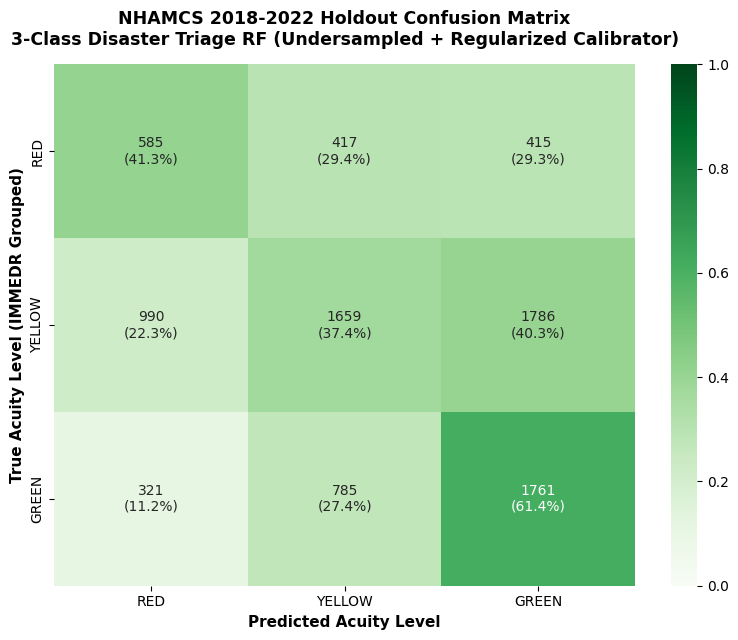

Confusion Matrix plot saved to: ../plots/nhamcs_rf_confusion_matrix.png


In [5]:
# ---------------------------------------------------------------------------
# Step 4: 3x3 Normalized Confusion Matrix Heatmap
# ---------------------------------------------------------------------------
plots_dir = f'{ROOT}/plots'
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(os.path.join(plots_dir, 'image'), exist_ok=True)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot_matrix = np.empty_like(cm, dtype=object)
for i in range(3):
    for j in range(3):
        annot_matrix[i, j] = f"{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)"

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    cm_norm,
    annot=annot_matrix,
    fmt='',
    cmap='Greens',
    cbar=True,
    xticklabels=LABELS,
    yticklabels=LABELS,
    ax=ax,
    vmin=0,
    vmax=1
)
ax.set_title('NHAMCS 2018-2022 Holdout Confusion Matrix\n3-Class Disaster Triage RF (Undersampled + Regularized Calibrator)', fontsize=12.5, fontweight='bold', pad=14)
ax.set_xlabel('Predicted Acuity Level', fontsize=11, fontweight='bold')
ax.set_ylabel('True Acuity Level (IMMEDR Grouped)', fontsize=11, fontweight='bold')

plt.tight_layout()
cm_out_path = os.path.join(plots_dir, 'nhamcs_rf_confusion_matrix.png')
plt.savefig(cm_out_path, dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'nhamcs_rf_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix plot saved to: {cm_out_path}")

In [6]:
# ---------------------------------------------------------------------------
# Step 5: Feature Density & Distribution Plots across Disaster Acuity Classes
# ---------------------------------------------------------------------------
density_dir = os.path.join(plots_dir, 'density_nhamcs_rf')
os.makedirs(density_dir, exist_ok=True)

df_train_plot = pd.DataFrame(X_train, columns=feature_names_24)
df_train_plot['Acuity_Level'] = [LABELS[k] for k in y_train_rus]

disaster_palette = {
    'RED': '#d62728',    # Red (Resuscitation / Emergent)
    'YELLOW': '#ff7f0e', # Orange (Urgent)
    'GREEN': '#2ca02c'   # Green (Semi-urgent / Nonurgent)
}

print(f"Generating density & distribution plots for all {len(feature_names_24)} clinical features...")
for feat in feature_names_24:
    fig, ax = plt.subplots(figsize=(8, 5))
    if feat == 'SEX' or feat.startswith('is_'):
        prop_df = df_train_plot.groupby('Acuity_Level')[feat].mean().reset_index(name='Proportion')
        sns.barplot(data=prop_df, x='Acuity_Level', y='Proportion', palette=disaster_palette, ax=ax, edgecolor='black',
                    order=LABELS)
        ax.set_title(f"{feat} (Prevalence by Disaster Acuity Level)", fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel("Acuity Level", fontsize=11, fontweight='bold')
        ax.set_ylabel("Prevalence / Proportion", fontsize=11, fontweight='bold')
        for p in ax.patches:
            ax.annotate(f"{p.get_height()*100:.1f}%",
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 2),
                        textcoords='offset points')
    else:
        sns.kdeplot(
            data=df_train_plot,
            x=feat,
            hue='Acuity_Level',
            hue_order=LABELS,
            palette=disaster_palette,
            common_norm=False,
            fill=True,
            alpha=0.20,
            linewidth=2.0,
            ax=ax
        )
        ax.set_title(f"NHAMCS Feature Density: {feat} across Acuity Classes", fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel(feat, fontsize=11, fontweight='bold')
        ax.set_ylabel("Density", fontsize=11, fontweight='bold')
        
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(density_dir, f"density_nhamcs_{feat}.png"), dpi=300, bbox_inches='tight')
    plt.close()

print(f"✓ All {len(feature_names_24)} feature density plots saved in: {density_dir}")

Generating density & distribution plots for all 24 clinical features...


✓ All 24 feature density plots saved in: ../plots/density_nhamcs_rf


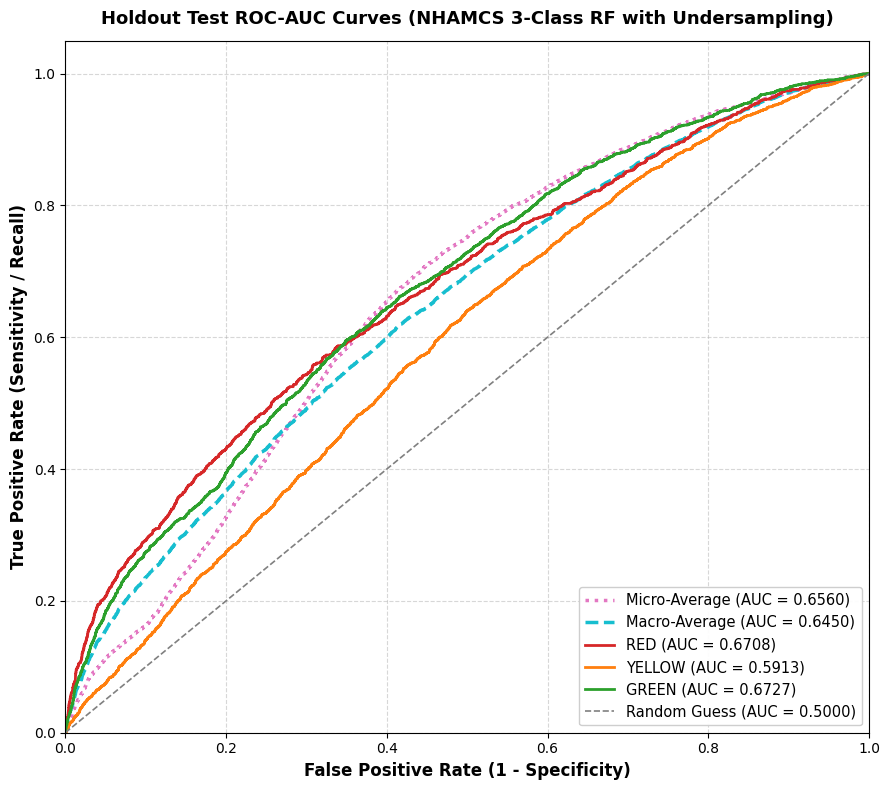

ROC-AUC curves saved to: ../plots/nhamcs_rf_roc_auc.png


In [7]:
# ---------------------------------------------------------------------------
# Step 6: 3-Class Multiclass ROC-AUC Curve Analysis
# ---------------------------------------------------------------------------
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes  = 3

fpr, tpr, roc_auc = dict(), dict(), dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], test_probs_calib[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), test_probs_calib.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(9, 8))
plt.plot(fpr["micro"], tpr["micro"],
         label=f"Micro-Average (AUC = {roc_auc['micro']:.4f})",
         color='#e377c2', linestyle=':', linewidth=2.5)
plt.plot(fpr["macro"], tpr["macro"],
         label=f"Macro-Average (AUC = {roc_auc['macro']:.4f})",
         color='#17becf', linestyle='--', linewidth=2.5)

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=disaster_palette[LABELS[i]], linewidth=2.0,
             label=f"{LABELS[i]} (AUC = {roc_auc[i]:.4f})")

plt.plot([0, 1], [0, 1], 'k--', color='gray', linewidth=1.2, label='Random Guess (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12, fontweight='bold')
plt.title('Holdout Test ROC-AUC Curves (NHAMCS 3-Class RF with Undersampling)', fontsize=13, fontweight='bold', pad=12)
plt.legend(loc="lower right", fontsize=10.5, frameon=True, framealpha=0.95)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

roc_out_path = os.path.join(plots_dir, 'nhamcs_rf_roc_auc.png')
plt.savefig(roc_out_path, dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'nhamcs_rf_roc_auc.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"ROC-AUC curves saved to: {roc_out_path}")

In [8]:
# ---------------------------------------------------------------------------
# Step 7: Export Production Bundle & Deployment Manifest
# ---------------------------------------------------------------------------
deploy_dir = f'{ROOT}/deploy'
os.makedirs(deploy_dir, exist_ok=True)

bundle_data = {
    'rf_model': rf_model,
    'calibrator': calibrator,
    'imputer': imputer,
    'base_feature_names': base_cols,
    'engineered_feature_names': feature_names_24,
    'labels': LABELS,
    'class_descriptions': CLASS_DESCRIPTIONS,
    'sampling_strategy': 'RandomUnderSampler'
}

bundle_file = os.path.join(deploy_dir, 'disaster_nhamcs_rf.pkl')
with open(bundle_file, 'wb') as f:
    pickle.dump(bundle_data, f)

manifest = dict(
    dataset='NHAMCS_2018_2022_Consolidated_ED',
    source_file=data_path,
    target='Disaster_Triage_3Class',
    model_type='RandomForestClassifier_With_Undersampling_And_L2_Calibrator',
    sampling='RandomUnderSampler',
    labels=LABELS,
    feature_order=feature_names_24,
    n_features=len(feature_names_24),
    n_nodes=n_nodes,
    flash_kb_approx=round(n_nodes * 16 / 1024, 2),
    calibrator_overhead_bytes=48,
    holdout_metrics={
        'overall_accuracy': round(float(overall_acc), 4),
        'balanced_accuracy_macro': round(float(bal_acc_macro), 4),
        'macro_roc_auc': round(float(roc_auc['macro']), 4),
        'micro_roc_auc': round(float(roc_auc['micro']), 4)
    }
)

manifest_file = os.path.join(deploy_dir, 'disaster_nhamcs_rf_manifest.json')
with open(manifest_file, 'w') as f:
    json.dump(manifest, f, indent=2)

print(f"✓ Exported Bundle:   {bundle_file}")
print(f"✓ Exported Manifest: {manifest_file}")

✓ Exported Bundle:   ../deploy/disaster_nhamcs_rf.pkl
✓ Exported Manifest: ../deploy/disaster_nhamcs_rf_manifest.json


In [9]:
# ---------------------------------------------------------------------------
# Step 8: Safety & Verification Assertions
# ---------------------------------------------------------------------------
assert len(feature_names_24) == 24, f'expected 24 features, got {len(feature_names_24)}'
assert overall_acc >= 0.40, f'Overall accuracy {overall_acc:.4f} below target'
assert bal_acc_macro >= 0.40, f'Balanced accuracy {bal_acc_macro:.4f} below target'
assert os.path.exists(bundle_file), f'{bundle_file} was not written'
assert os.path.exists(manifest_file), f'{manifest_file} was not written'
print('✓ All NHAMCS 2018-2022 3-Class Disaster Triage RF (with Undersampling) assertions passed!')

✓ All NHAMCS 2018-2022 3-Class Disaster Triage RF (with Undersampling) assertions passed!
